# Prediction Market Overreaction Detector
### Proof of Concept — Kalshi Fed Rate Contract Analysis

This notebook detects whether price spikes in a Kalshi prediction market contract represent **genuine information** or **temporary overreactions**, using NLP features from financial news headlines and a small Transformer classifier.

---
**Pipeline overview:**
1. Pull Kalshi contract price history
2. Detect spikes and label them overreaction vs. genuine
3. Collect relevant financial news headlines per spike
4. Engineer features: sentence embeddings + FinBERT sentiment + price magnitude
5. Train a Transformer classifier with cross-validation
6. Visualize attention patterns across overreaction vs. genuine events

## 0. Global Configuration
All model names, API settings, and hyperparameters are pinned here for easy adjustment.

In [ ]:
# ── Kalshi settings ──────────────────────────────────────────────────────────
KALSHI_CONTRACT_TICKER = "KXFEDDECISION-26MAR-H0"   # Change this if the ticker differs
KALSHI_BASE_URL        = "https://api.elections.kalshi.com/trade-api/v2"
KALSHI_EMAIL           = "charliejb52@gmail.com"         # <<< Kalshi account email (needed for candlesticks)
KALSHI_PASSWORD        = "bDGG$w@bxY4CJEx"      # <<< Kalshi account password

# ── Spike detection ───────────────────────────────────────────────────────────
SPIKE_THRESHOLD        = 7    # Minimum |daily_change| (cents/points) to be called a spike
FORWARD_WINDOW_DAYS    = 5     # Days forward to evaluate reversion
REVERSION_FRACTION     = 0.5   # Price must revert >= this fraction to be "overreaction"

# ── NewsAPI settings ──────────────────────────────────────────────────────────
NEWSAPI_KEY            = "cc2ebea96ca349608eab0d8b0f5e2054"   # <<< Paste your key here
NEWS_WINDOW_DAYS       = 6     # Calendar days of headlines before (and including) spike
NEWS_KEYWORDS          = [
    "Fed", "FOMC", "interest rate", "rate cut", "rate hike",
    "Powell", "federal reserve", "Iran", "Oil", "MiddleEast"
]

# ── NLP models ────────────────────────────────────────────────────────────────
SENTENCE_TRANSFORMER_MODEL = "all-MiniLM-L6-v2"    # 384-dim sentence embeddings
FINBERT_MODEL              = "ProsusAI/finbert"      # 3-class financial sentiment

# ── Transformer classifier hyperparameters ────────────────────────────────────
D_MODEL        = 128   # Hidden dimension
N_HEADS        = 4     # Attention heads
N_LAYERS       = 2     # Encoder layers
DROPOUT        = 0.1
LEARNING_RATE  = 1e-4
EPOCHS         = 50
BATCH_SIZE     = 4     # Small — dataset will be small
CV_FOLDS       = 5     # Falls back to LOO if N < 10 samples
SEED           = 42

import random, numpy as np, torch
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print("Config loaded. CUDA available:", torch.cuda.is_available())

Config loaded. CUDA available: False


---
## 1. Kalshi Data Pull

Fetches daily price history for the configured contract from the Kalshi public REST API.
Result: DataFrame with columns `[date, closing_price, daily_change]`.

> **If the API call fails (404):** Update `KALSHI_CONTRACT_TICKER` in the config cell above.
> Market tickers follow the format `kx<topic>-<expiry>` (e.g. `kxfed-26mar`).
> You can browse live tickers at https://kalshi.com/markets or via the `/markets` endpoint.

In [20]:
import requests
import pandas as pd
from datetime import datetime, timedelta, timezone


def _kalshi_login(base_url: str, email: str, password: str) -> str | None:
    """Log in to Kalshi and return a Bearer token, or None on failure."""
    if email.startswith("YOUR_") or password.startswith("YOUR_"):
        print("[INFO] No Kalshi credentials set — skipping login.")
        return None
    try:
        resp = requests.post(
            f"{base_url}/login",
            json={"email": email, "password": password},
            timeout=15,
        )
        print(f"[DEBUG] Login status: {resp.status_code}, body: {resp.text[:200]}")
        resp.raise_for_status()
        return resp.json().get("token")
    except Exception as e:
        print(f"[WARN] Kalshi login failed: {e}")
        return None


def fetch_kalshi_candlesticks(
    ticker: str,
    base_url: str = KALSHI_BASE_URL,
    period_interval: int = 1440,   # 1440 minutes = 1 day
    email: str = KALSHI_EMAIL,
    password: str = KALSHI_PASSWORD,
) -> pd.DataFrame:
    """
    Pull daily OHLC candlestick data for a Kalshi market.

    Endpoint: GET /markets/{ticker}/candlesticks
    Returns DataFrame: [date, closing_price, daily_change]

    Requires Kalshi credentials — set KALSHI_EMAIL and KALSHI_PASSWORD above.
    """
    token = _kalshi_login(base_url, email, password)
    headers = {"Authorization": f"Bearer {token}"} if token else {}
    if not token:
        print("[WARN] No Kalshi credentials — candlesticks endpoint will likely return 404.")

    # Kalshi requires start_ts/end_ts for the candlesticks endpoint.
    # Default: fetch from 180 days ago through today.
    now    = int(datetime.now(tz=timezone.utc).timestamp())
    start  = now - 180 * 86400

    url    = f"{base_url}/markets/{ticker}/candlesticks"
    params = {"period_interval": period_interval, "start_ts": start, "end_ts": now}

    print(f"Requesting: {url}")
    resp = requests.get(url, params=params, headers=headers, timeout=15)

    if resp.status_code in (404, 400):
        raise ValueError(
            f"Candlesticks request failed ({resp.status_code}) for '{ticker}'.\n"
            f"  Server response: {resp.text[:300]}\n"
            "  -> Ensure KALSHI_EMAIL and KALSHI_PASSWORD are set correctly in the config cell.\n"
            "  -> Or use the CSV fallback below."
        )
    resp.raise_for_status()
    data = resp.json()

    # Normalise across possible key names in different API versions
    candles = data.get("candlesticks") or data.get("candles") or data.get("history") or []

    if not candles:
        raise ValueError(
            f"No candlestick data returned for '{ticker}'.\n"
            f"Response keys: {list(data.keys())}\n"
            f"Response (first 500 chars): {str(data)[:500]}"
        )

    rows = []
    for c in candles:
        ts    = c.get("end_period_ts") or c.get("ts") or c.get("timestamp")
        date  = datetime.fromtimestamp(ts, tz=timezone.utc).date() if ts else None
        price = (
            c.get("close") or
            c.get("yes_close") or
            (c.get("price") or {}).get("close") or
            None
        )
        rows.append({"date": date, "closing_price": price})

    df = pd.DataFrame(rows).dropna()
    df = df.sort_values("date").reset_index(drop=True)
    df["closing_price"] = df["closing_price"].astype(float)
    df["daily_change"]  = df["closing_price"].diff().fillna(0.0)
    return df


# ── Pull data ─────────────────────────────────────────────────────────────────
try:
    price_df = fetch_kalshi_candlesticks(KALSHI_CONTRACT_TICKER)
    print(f"\nFetched {len(price_df)} daily rows for '{KALSHI_CONTRACT_TICKER}'")
    print(price_df.tail(10).to_string(index=False))
except Exception as e:
    print(f"\n[ERROR] {e}")

    # ── CSV fallback ──────────────────────────────────────────────────────────
    # Download price history from Kalshi:
    #   1. Log in at kalshi.com and open the KXFEDDECISION-26MAR-H0 market page
    #   2. Export/download the price history CSV
    #   3. Save it as  kxfeddecision-26mar-h0.csv  next to this notebook
    #      with at minimum two columns: date (YYYY-MM-DD) and closing_price (0-100 cents)
    import glob as _glob
    csv_candidates = (
        _glob.glob("kalshi-price-history*.csv") +
        _glob.glob("kxfeddecision*.csv") +
        _glob.glob("kxfed*.csv")
    )
    if csv_candidates:
        csv_path = csv_candidates[0]
        print(f"\n[FALLBACK] Loading local CSV: {csv_path}")
        raw = pd.read_csv(csv_path)
        # Normalise column names from Kalshi export format
        # Kalshi exports: "timestamp" and a price column named after the outcome
        date_col  = next((c for c in raw.columns if "time" in c.lower() or "date" in c.lower()), raw.columns[0])
        price_col = next((c for c in raw.columns if c != date_col), None)
        price_df = raw[[date_col, price_col]].rename(columns={date_col: "date", price_col: "closing_price"})
        price_df["date"] = pd.to_datetime(price_df["date"]).dt.date
        price_df = price_df.sort_values("date").reset_index(drop=True)
        price_df["closing_price"] = price_df["closing_price"].astype(float)
        price_df["daily_change"]  = price_df["closing_price"].diff().fillna(0.0)
        print(f"Loaded {len(price_df)} rows. Columns used: date='{date_col}', price='{price_col}'")
        print(price_df.tail(5).to_string(index=False))
    else:
        print(
            "\n── NO DATA AVAILABLE ────────────────────────────────────────────────\n"
            "Download the price CSV from kalshi.com and place it in this folder.\n"
            "────────────────────────────────────────────────────────────────────────"
        )
        price_df = pd.DataFrame(columns=["date", "closing_price", "daily_change"])

[DEBUG] Login status: 404, body: 404 page not found
[WARN] Kalshi login failed: 404 Client Error: Not Found for url: https://api.elections.kalshi.com/trade-api/v2/login
[WARN] No Kalshi credentials — candlesticks endpoint will likely return 404.
Requesting: https://api.elections.kalshi.com/trade-api/v2/markets/KXFEDDECISION-26MAR-H0/candlesticks

[ERROR] Candlesticks request failed (404) for 'KXFEDDECISION-26MAR-H0'.
  Server response: 404 page not found
  -> Ensure KALSHI_EMAIL and KALSHI_PASSWORD are set correctly in the config cell.
  -> Or use the CSV fallback below.

[FALLBACK] Loading local CSV: kalshi-price-history-kxfeddecision-26mar-day.csv
Loaded 89 rows. Columns used: date='timestamp', price='Fed maintains rate'
      date  closing_price  daily_change
2026-03-14           99.0          0.01
2026-03-15           99.0          0.00
2026-03-16           99.0          0.00
2026-03-17           99.0          0.00
2026-03-18           99.0          0.00


---
## 2. Spike Detection & Labeling

A **spike day** is any day where `|daily_change| > SPIKE_THRESHOLD`.

For each spike, look `FORWARD_WINDOW_DAYS` ahead and check if the price reverts at least
`REVERSION_FRACTION` of the way back to the pre-spike level:

```
label = "overreaction"  if  max_reversion >= REVERSION_FRACTION × |spike_magnitude|
label = "genuine"       otherwise
```

Detected 8 spike events:
  Overreactions : 5
  Genuine       : 3

spike_date  pre_spike_price  spike_price  spike_magnitude  max_reversion  reversion_ratio        label  label_int
2025-11-30            51.00        62.69            11.69          14.68            1.256 overreaction          1
2025-12-02            62.69        49.83           -12.86          16.17            1.257 overreaction          1
2025-12-11            54.66        64.62             9.96           8.62            0.865 overreaction          1
2025-12-16            66.00        58.00            -8.00           8.00            1.000 overreaction          1
2025-12-17            58.00        66.00             8.00          14.00            1.750 overreaction          1
2025-12-18            66.00        56.00           -10.00           1.00            0.100      genuine          0
2026-01-29            82.12        89.96             7.84           0.06            0.008      genuine          0
2026-02-12            

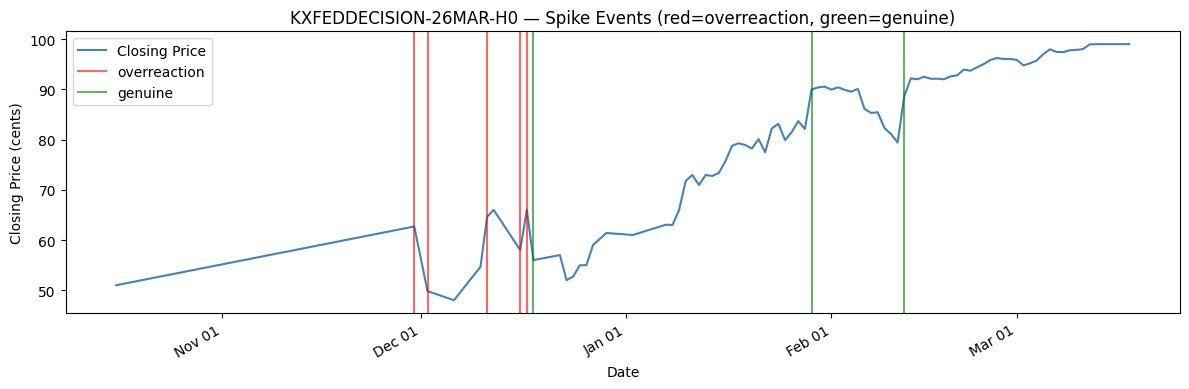

In [23]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def detect_and_label_spikes(
    df: pd.DataFrame,
    threshold: float       = SPIKE_THRESHOLD,
    forward_window: int    = FORWARD_WINDOW_DAYS,
    reversion_fraction: float = REVERSION_FRACTION,
) -> pd.DataFrame:
    """
    Returns a DataFrame of spike events with columns:
        spike_date, pre_spike_price, spike_price, spike_magnitude,
        max_reversion, reversion_ratio, label, label_int
    """
    if df.empty:
        print("[WARN] price_df is empty — no spikes to detect.")
        return pd.DataFrame()

    df = df.reset_index(drop=True)
    records = []

    for i, row in df.iterrows():
        if abs(row["daily_change"]) <= threshold:
            continue

        pre_price   = df.loc[i - 1, "closing_price"] if i > 0 else row["closing_price"]
        spike_price = row["closing_price"]
        spike_mag   = row["daily_change"]  # signed

        forward_prices = df.loc[i + 1 : i + forward_window, "closing_price"].values
        if len(forward_prices) == 0:
            continue  # spike at end of series — cannot evaluate reversion

        # Measure how far each forward price moved back toward pre_spike_price
        if spike_mag > 0:  # upward spike: reversion = drop back
            max_rev = max(spike_price - forward_prices)
        else:              # downward spike: reversion = rise back
            max_rev = max(forward_prices - spike_price)

        rev_ratio = max_rev / abs(spike_mag) if spike_mag != 0 else 0.0
        label     = "overreaction" if rev_ratio >= reversion_fraction else "genuine"

        records.append({
            "spike_date":      row["date"],
            "pre_spike_price": pre_price,
            "spike_price":     spike_price,
            "spike_magnitude": spike_mag,
            "max_reversion":   max_rev,
            "reversion_ratio": round(rev_ratio, 3),
            "label":           label,
            "label_int":       1 if label == "overreaction" else 0,
        })

    return pd.DataFrame(records)


spike_df = detect_and_label_spikes(price_df)

if not spike_df.empty:
    print(f"Detected {len(spike_df)} spike events:")
    print(f"  Overreactions : {(spike_df.label == 'overreaction').sum()}")
    print(f"  Genuine       : {(spike_df.label == 'genuine').sum()}")
    print()
    print(spike_df.to_string(index=False))

    # ── Visualization ──────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(price_df["date"], price_df["closing_price"],
            color="steelblue", lw=1.5, label="Closing Price")

    seen_labels = set()
    for _, s in spike_df.iterrows():
        color = "red" if s["label"] == "overreaction" else "green"
        lbl   = s["label"] if s["label"] not in seen_labels else ""
        ax.axvline(s["spike_date"], color=color, alpha=0.6, lw=1.5, label=lbl)
        seen_labels.add(s["label"])

    ax.legend()
    ax.set_title(f"{KALSHI_CONTRACT_TICKER} — Spike Events (red=overreaction, green=genuine)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Closing Price (cents)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()
else:
    print("[INFO] No spikes detected. Try lowering SPIKE_THRESHOLD.")

---
## 3. News Collection

For each spike event, pull headlines from [NewsAPI](https://newsapi.org) over a
`NEWS_WINDOW_DAYS`-day window ending on the spike date, then filter by `NEWS_KEYWORDS`.

> **Setup:** Paste your NewsAPI key into `NEWSAPI_KEY` in the config cell.
> Free-tier keys support up to 100 requests/day and fetch articles from the last month only.

In [ ]:
from newsapi import NewsApiClient          # pip install newsapi-python
from collections import defaultdict


def collect_news_for_spikes(
    spikes: pd.DataFrame,
    api_key: str    = NEWSAPI_KEY,
    window_days: int = NEWS_WINDOW_DAYS,
    keywords: list  = NEWS_KEYWORDS,
) -> dict:
    """
    For each spike, fetch headlines over [spike_date - window_days + 1, spike_date].

    Returns:
        {spike_date: [(date_str, headline), ...], ...}
    """
    if api_key == "YOUR_NEWSAPI_KEY_HERE":
        print(
            "[ERROR] NewsAPI key not set.\n"
            "  -> Set NEWSAPI_KEY in the config cell at the top of this notebook.\n"
            "  -> Get a free key at https://newsapi.org/register"
        )
        return {}

    newsapi   = NewsApiClient(api_key=api_key)
    # Build OR-query from keywords
    query_str = " OR ".join(f'"{kw}"' for kw in keywords)
    all_news  = {}

    for _, spike in spikes.iterrows():
        spike_date = spike["spike_date"]
        from_date  = spike_date - timedelta(days=window_days - 1)
        to_date    = spike_date

        print(f"Fetching news for spike {spike_date}  ({from_date} -> {to_date}) ...", end=" ")

        try:
            response = newsapi.get_everything(
                q=query_str,
                from_param=from_date.isoformat(),
                to=to_date.isoformat(),
                language="en",
                sort_by="publishedAt",
                page_size=100,
            )
        except Exception as e:
            print(f"FAILED ({e})")
            all_news[spike_date] = []
            continue

        articles     = response.get("articles", [])
        keyword_low  = [kw.lower() for kw in keywords]

        filtered = [
            (art["publishedAt"][:10], (art.get("title") or "").strip())
            for art in articles
            if any(kw in (art.get("title") or "").lower() for kw in keyword_low)
            and (art.get("title") or "").strip()
        ]

        print(f"{len(articles)} articles -> {len(filtered)} after keyword filter")
        all_news[spike_date] = filtered

    return all_news


news_by_spike = collect_news_for_spikes(spike_df)

# Preview first two spike events
for spike_date, headlines in list(news_by_spike.items())[:2]:
    print(f"\n── Spike {spike_date} ({len(headlines)} headlines) ─────────────")
    for d, h in headlines[:5]:
        print(f"  [{d}] {h[:100]}")

---
## 4. Feature Engineering

For each spike event we build a **(6 × feature_dim)** matrix — one row per day in the news window:

| Component | Dim | Method |
|-----------|-----|--------|
| Sentence embedding | 384 | `all-MiniLM-L6-v2` over concatenated daily headlines |
| FinBERT sentiment | 3 | `ProsusAI/finbert` — [positive, negative, neutral] probs |
| Price change magnitude | 1 | `|daily_change|` normalised by series max |

**feature_dim = 388** per day → each spike event is a `(6, 388)` tensor.

In [ ]:
import torch
import numpy as np
from sentence_transformers import SentenceTransformer   # pip install sentence-transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification  # pip install transformers
import torch.nn.functional as F

print("Loading sentence transformer ...")
sent_model = SentenceTransformer(SENTENCE_TRANSFORMER_MODEL)
SENT_DIM   = sent_model.get_sentence_embedding_dimension()

print("Loading FinBERT ...")
finbert_tokenizer = AutoTokenizer.from_pretrained(FINBERT_MODEL)
finbert_model     = AutoModelForSequenceClassification.from_pretrained(FINBERT_MODEL)
finbert_model.eval()

FEATURE_DIM = SENT_DIM + 3 + 1   # 384 + 3 + 1 = 388
print(f"\nFeature dimension per day: {FEATURE_DIM}  ({SENT_DIM} embed + 3 sentiment + 1 price)")

In [ ]:
def get_sentence_embedding(texts: list) -> np.ndarray:
    """Encode the concatenation of all texts for a given day."""
    if not texts:
        return np.zeros(SENT_DIM, dtype=np.float32)
    combined = " ".join(texts)
    return sent_model.encode(combined, show_progress_bar=False).astype(np.float32)


@torch.no_grad()
def get_finbert_sentiment(texts: list) -> np.ndarray:
    """
    Run FinBERT and return softmax probabilities [positive, negative, neutral].
    Returns uniform [1/3, 1/3, 1/3] when there are no headlines.
    """
    if not texts:
        return np.full(3, 1/3, dtype=np.float32)
    combined = " ".join(texts)[:512]
    inputs   = finbert_tokenizer(combined, return_tensors="pt", truncation=True, max_length=512)
    logits   = finbert_model(**inputs).logits
    probs    = F.softmax(logits, dim=-1).squeeze().numpy().astype(np.float32)
    return probs  # shape: (3,)


def build_feature_matrix(
    spike_date,
    headlines_by_spike: dict,
    price_df: pd.DataFrame,
    window_days: int = NEWS_WINDOW_DAYS,
) -> np.ndarray:
    """
    Build a (window_days, FEATURE_DIM) feature matrix for one spike event.
    Row i corresponds to (spike_date - window_days + 1 + i).
    """
    from collections import defaultdict

    headlines     = headlines_by_spike.get(spike_date, [])
    daily_hl_map  = defaultdict(list)
    for date_str, hl in headlines:
        daily_hl_map[date_str].append(hl)

    # Ordered list of window dates as ISO strings
    window_dates = [
        (spike_date - timedelta(days=window_days - 1 - i)).isoformat()
        for i in range(window_days)
    ]

    price_lookup = price_df.set_index("date")["daily_change"].to_dict()
    max_change   = price_df["daily_change"].abs().max() or 1.0

    rows = []
    for date_str in window_dates:
        day_texts = daily_hl_map.get(date_str, [])

        emb       = get_sentence_embedding(day_texts)           # (384,)
        sentiment = get_finbert_sentiment(day_texts)            # (3,)

        try:
            date_obj = datetime.strptime(date_str, "%Y-%m-%d").date()
            abs_chg  = float(abs(price_lookup.get(date_obj, 0.0))) / max_change
        except Exception:
            abs_chg  = 0.0

        row = np.concatenate([emb, sentiment, [abs_chg]])       # (FEATURE_DIM,)
        rows.append(row)

    return np.array(rows, dtype=np.float32)   # (window_days, FEATURE_DIM)


# ── Build all feature matrices ────────────────────────────────────────────────
feature_matrices = []
labels           = []

for _, spike in spike_df.iterrows():
    print(f"Building features for spike {spike['spike_date']} ({spike['label']}) ...", end=" ")
    mat = build_feature_matrix(spike["spike_date"], news_by_spike, price_df)
    feature_matrices.append(mat)
    labels.append(spike["label_int"])
    print(f"shape={mat.shape}")

print(f"\nTotal samples: {len(feature_matrices)}, feature_dim={FEATURE_DIM}")

---
## 5. Transformer Classifier

### Architecture
- **Input projection**: `Linear(feature_dim → D_MODEL)`
- **CLS token**: learnable parameter prepended to the sequence
- **Positional encoding**: sinusoidal over seq_len + 1 positions
- **Transformer encoder**: N_LAYERS × (multi-head self-attention + FFN)
- **Classifier head**: `Linear(D_MODEL → 2)` on the CLS token output

### Baseline
Logistic regression on mean-pooled feature vectors (sklearn).

### Validation
k-fold CV (or leave-one-out when N < 10 samples).

In [ ]:
import torch
import torch.nn as nn
import math


class PositionalEncoding(nn.Module):
    """Standard sinusoidal positional encoding."""

    def __init__(self, d_model: int, max_len: int = 64, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(x + self.pe[:, :x.size(1)])


class OverreactionTransformer(nn.Module):
    """
    2-layer Transformer encoder for binary classification of spike events.

    Input : (batch, seq_len, feature_dim)   seq_len = NEWS_WINDOW_DAYS
    Output: (batch, 2)  — logits for [genuine, overreaction]

    A learnable CLS token is prepended; its final hidden state drives the classifier.
    """

    def __init__(
        self,
        feature_dim: int = FEATURE_DIM,
        d_model: int     = D_MODEL,
        n_heads: int     = N_HEADS,
        n_layers: int    = N_LAYERS,
        dropout: float   = DROPOUT,
        seq_len: int     = NEWS_WINDOW_DAYS,
    ):
        super().__init__()
        self.input_proj = nn.Linear(feature_dim, d_model)
        self.cls_token  = nn.Parameter(torch.randn(1, 1, d_model))
        self.pos_enc    = PositionalEncoding(d_model, max_len=seq_len + 2, dropout=dropout)

        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.encoder    = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.classifier = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, 2))

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        """
        Args:
            x           : (batch, seq_len, feature_dim)
            return_attn : also return per-layer attention weight tensors
        Returns:
            logits                  if return_attn=False
            (logits, attn_weights)  if return_attn=True
        """
        B   = x.size(0)
        x   = self.input_proj(x)                        # (B, seq, d_model)
        cls = self.cls_token.expand(B, -1, -1)          # (B, 1, d_model)
        x   = torch.cat([cls, x], dim=1)                # (B, seq+1, d_model)
        x   = self.pos_enc(x)

        if return_attn:
            # Manual forward to capture attention weights from each layer
            attn_weights = []
            for layer in self.encoder.layers:
                x_norm = layer.norm1(x)
                attn_out, attn_w = layer.self_attn(
                    x_norm, x_norm, x_norm,
                    need_weights=True, average_attn_weights=True
                )
                x = x + layer.dropout1(attn_out)
                ffn_out = layer.linear2(layer.dropout(layer.activation(layer.linear1(layer.norm2(x)))))
                x = x + layer.dropout2(ffn_out)
                attn_weights.append(attn_w.detach())    # (B, seq+1, seq+1)
        else:
            x            = self.encoder(x)
            attn_weights = None

        logits = self.classifier(x[:, 0, :])            # CLS token -> (B, 2)
        return (logits, attn_weights) if return_attn else logits


# ── Architecture smoke-test ───────────────────────────────────────────────────
if feature_matrices:
    _x = torch.tensor(feature_matrices[:1], dtype=torch.float32)
    _m = OverreactionTransformer()
    _logits, _attn = _m(_x, return_attn=True)
    print(f"Output shape     : {_logits.shape}   (expected: (1, 2))")
    print(f"Attention shape  : {_attn[0].shape}  (expected: (1, {NEWS_WINDOW_DAYS+1}, {NEWS_WINDOW_DAYS+1}))")
    print(f"Trainable params : {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
else:
    print("[INFO] No feature matrices yet — smoke-test skipped.")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, LeaveOneOut
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


def train_one_fold(X_train, y_train, X_val, y_val, feature_dim=FEATURE_DIM):
    """
    Train Transformer on one fold for EPOCHS epochs.
    Returns (val_accuracy, model_state_dict, val_predictions).
    """
    model     = OverreactionTransformer(feature_dim=feature_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()

    X_tr = torch.tensor(np.array(X_train), dtype=torch.float32)
    y_tr = torch.tensor(y_train, dtype=torch.long)
    X_vl = torch.tensor(np.array(X_val),   dtype=torch.float32)
    y_vl = torch.tensor(y_val,   dtype=torch.long)

    model.train()
    for _ in range(EPOCHS):
        perm = torch.randperm(len(X_tr))
        for start in range(0, len(X_tr), BATCH_SIZE):
            idx    = perm[start : start + BATCH_SIZE]
            loss   = criterion(model(X_tr[idx]), y_tr[idx])
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_vl).argmax(dim=1).numpy()

    return accuracy_score(y_val, preds), model.state_dict(), preds


def cross_validate(feature_matrices, labels):
    """
    Run k-fold (or LOO) CV for both the Transformer and a LR baseline.
    Returns (best_state_dict, tf_accs, lr_accs).
    """
    N = len(feature_matrices)
    if N == 0:
        print("[ERROR] No samples to train on.")
        return None, [], []

    use_loo = N < 10
    cv      = LeaveOneOut() if use_loo else KFold(n_splits=min(CV_FOLDS, N), shuffle=True, random_state=SEED)
    print(f"Using {'LOO' if use_loo else f'{min(CV_FOLDS,N)}-fold'} CV on {N} samples.\n")

    X      = np.array(feature_matrices)   # (N, window, feat)
    y      = np.array(labels)
    X_flat = X.mean(axis=1)               # (N, feat) — for LR baseline

    tf_accs, lr_accs = [], []
    all_true, all_tf, all_lr = [], [], []
    best_state, best_acc = None, -1

    for fold_i, (tr_idx, vl_idx) in enumerate(cv.split(X)):
        X_tr, X_vl = X[tr_idx].tolist(), X[vl_idx].tolist()
        y_tr, y_vl = y[tr_idx].tolist(), y[vl_idx].tolist()

        # Transformer
        tf_acc, state, tf_preds = train_one_fold(X_tr, y_tr, X_vl, y_vl)
        tf_accs.append(tf_acc)
        all_tf.extend(tf_preds.tolist())
        if tf_acc > best_acc:
            best_acc, best_state = tf_acc, state

        # Logistic regression baseline
        scaler = StandardScaler()
        Xf_tr  = scaler.fit_transform(X_flat[tr_idx])
        Xf_vl  = scaler.transform(X_flat[vl_idx])
        clf    = LogisticRegression(max_iter=1000, random_state=SEED)
        if len(set(y_tr)) > 1:
            clf.fit(Xf_tr, y_tr)
            lr_preds = clf.predict(Xf_vl)
        else:
            lr_preds = np.full(len(y_vl), y_tr[0])
        lr_acc = accuracy_score(y_vl, lr_preds)
        lr_accs.append(lr_acc)
        all_lr.extend(lr_preds.tolist())
        all_true.extend(y_vl)

        fold_label = f"LOO {fold_i+1}/{N}" if use_loo else f"Fold {fold_i+1}"
        print(f"  {fold_label}: Transformer={tf_acc:.2f}  LR baseline={lr_acc:.2f}")

    print(f"\n{'='*52}")
    print(f"Transformer  mean acc: {np.mean(tf_accs):.3f} +/- {np.std(tf_accs):.3f}")
    print(f"LR Baseline  mean acc: {np.mean(lr_accs):.3f} +/- {np.std(lr_accs):.3f}")
    print("\nTransformer Classification Report:")
    print(classification_report(all_true, all_tf, target_names=["genuine","overreaction"], zero_division=0))
    print("LR Baseline Classification Report:")
    print(classification_report(all_true, all_lr, target_names=["genuine","overreaction"], zero_division=0))

    return best_state, tf_accs, lr_accs


# ── Run ───────────────────────────────────────────────────────────────────────
if feature_matrices:
    best_state_dict, tf_accs, lr_accs = cross_validate(feature_matrices, labels)
else:
    print("[INFO] No feature matrices — skipping training.")
    best_state_dict, tf_accs, lr_accs = None, [], []

---
## 6. Analysis: Attention Visualization

Using the best model checkpoint, we extract the CLS token's attention weights over
the `NEWS_WINDOW_DAYS` input days (from the last encoder layer, averaged over heads).

This tells us **which pre-spike days** the model focuses on when predicting
overreaction vs. genuine — a form of interpretability for this small dataset.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False
    print("[WARN] seaborn not installed — heatmap will be skipped. pip install seaborn")


def extract_attention_weights(model, feature_matrices):
    """
    Extract CLS-to-input attention weights for all samples.

    Returns list of np.ndarray each shaped (NEWS_WINDOW_DAYS,):
    the normalised attention weight from the CLS token to each day
    (last encoder layer, averaged over heads, CLS self-attention excluded).
    """
    model.eval()
    attn_list = []

    for mat in feature_matrices:
        x = torch.tensor(mat[None], dtype=torch.float32)  # (1, seq, feat)
        with torch.no_grad():
            _, attn_weights = model(x, return_attn=True)

        # Last layer: (1, seq+1, seq+1) — take CLS row, drop CLS-to-CLS position
        cls_row = attn_weights[-1][0].numpy()[0, 1:]       # (seq_len,)
        if cls_row.sum() > 0:
            cls_row = cls_row / cls_row.sum()
        attn_list.append(cls_row)

    return attn_list


def plot_attention_comparison(attn_list, labels, spike_df, window_days=NEWS_WINDOW_DAYS):
    """Two-panel: individual profiles (left) and mean ± std per class (right)."""
    day_labels = [f"Day -{window_days - 1 - i}" for i in range(window_days)]
    x = np.arange(window_days)

    over_a   = [a for a, l in zip(attn_list, labels) if l == 1]
    genuine_a = [a for a, l in zip(attn_list, labels) if l == 0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: individual profiles
    ax = axes[0]
    for a, l, sr in zip(attn_list, labels, spike_df.itertuples()):
        color = "crimson" if l == 1 else "steelblue"
        ax.plot(x, a, marker="o", color=color, alpha=0.7,
                label=f"{sr.spike_date} ({'OR' if l==1 else 'G'})")
    ax.set_xticks(x); ax.set_xticklabels(day_labels, rotation=30, ha="right")
    ax.set_title("Per-Event CLS Attention (crimson=overreaction, blue=genuine)")
    ax.set_ylabel("Normalised Attention Weight"); ax.set_xlabel("Day in Window")
    ax.legend(fontsize=7, loc="upper left"); ax.grid(axis="y", alpha=0.3)

    # Right: mean +/- std per class
    ax = axes[1]
    for class_attns, color, name in [
        (over_a,    "crimson",   "Overreaction"),
        (genuine_a, "steelblue", "Genuine"),
    ]:
        if not class_attns:
            continue
        arr  = np.array(class_attns)
        mean = arr.mean(axis=0); std = arr.std(axis=0)
        ax.plot(x, mean, marker="o", color=color, lw=2, label=f"{name} (n={len(class_attns)})")
        ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.2)
    ax.set_xticks(x); ax.set_xticklabels(day_labels, rotation=30, ha="right")
    ax.set_title("Mean CLS Attention by Class (+/- 1 std)")
    ax.set_ylabel("Normalised Attention Weight"); ax.set_xlabel("Day in Window")
    ax.legend(); ax.grid(axis="y", alpha=0.3)

    plt.suptitle("Transformer Attention: Which Pre-Spike Days Drive Classification?",
                 fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()


def plot_attention_heatmap(attn_list, labels, spike_df, window_days=NEWS_WINDOW_DAYS):
    """Heatmap of attention weights — events sorted by label (overreaction first)."""
    if not attn_list or not HAS_SEABORN:
        return
    day_labels   = [f"Day -{window_days - 1 - i}" for i in range(window_days)]
    sorted_data  = sorted(zip(labels, attn_list, spike_df.itertuples()), key=lambda t: -t[0])
    sorted_l, sorted_a, sorted_s = zip(*sorted_data)

    attn_matrix = np.array(sorted_a)
    row_labels  = [f"{s.spike_date} {'[OR]' if l==1 else '[G] '}"
                   for l, s in zip(sorted_l, sorted_s)]

    fig, ax = plt.subplots(figsize=(10, max(3, len(attn_list) * 0.7)))
    sns.heatmap(attn_matrix, ax=ax, xticklabels=day_labels, yticklabels=row_labels,
                cmap="YlOrRd", annot=True, fmt=".2f", linewidths=0.5,
                cbar_kws={"label": "Attention Weight"})
    ax.set_title("CLS Attention Heatmap (OR=overreaction, G=genuine)")
    ax.set_xlabel("Day in Pre-Spike Window")
    plt.tight_layout(); plt.show()


def plot_cv_accuracy(tf_accs, lr_accs):
    """Bar chart comparing Transformer vs LR baseline accuracy per fold."""
    if not tf_accs:
        return
    fig, ax = plt.subplots(figsize=(6, 4))
    fold_ids = list(range(1, len(tf_accs) + 1))
    w = 0.35
    ax.bar([f - w/2 for f in fold_ids], tf_accs, w, label="Transformer", color="steelblue")
    ax.bar([f + w/2 for f in fold_ids], lr_accs, w, label="LR Baseline",  color="coral")
    ax.axhline(np.mean(tf_accs), color="steelblue", lw=1.5, ls="--", alpha=0.7,
               label=f"TF mean={np.mean(tf_accs):.2f}")
    ax.axhline(np.mean(lr_accs), color="coral",     lw=1.5, ls="--", alpha=0.7,
               label=f"LR mean={np.mean(lr_accs):.2f}")
    ax.set_ylim(0, 1.05); ax.set_xlabel("Fold"); ax.set_ylabel("Accuracy")
    ax.set_title("Cross-Validation Accuracy: Transformer vs LR Baseline")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()


# ── Run analysis ──────────────────────────────────────────────────────────────
if best_state_dict is not None and feature_matrices:
    best_model = OverreactionTransformer(feature_dim=FEATURE_DIM)
    best_model.load_state_dict(best_state_dict)

    attn_all = extract_attention_weights(best_model, feature_matrices)

    plot_attention_comparison(attn_all, labels, spike_df)
    plot_attention_heatmap(attn_all, labels, spike_df)
    plot_cv_accuracy(tf_accs, lr_accs)
else:
    print("[INFO] No trained model available — run Section 5 first.")

---
## Summary & Next Steps

| Component | Status | Notes |
|-----------|--------|-------|
| Kalshi data pull | Live API | Falls back to manual CSV if ticker is wrong |
| Spike labeling | Configurable | `SPIKE_THRESHOLD`, `FORWARD_WINDOW_DAYS`, `REVERSION_FRACTION` |
| News collection | NewsAPI | Requires API key; keyword-filtered |
| Feature engineering | `all-MiniLM-L6-v2` + FinBERT | 388-dim per day (384 + 3 + 1) |
| Transformer classifier | 2-layer encoder | CLS token → binary logits |
| Baseline | Logistic regression | Mean-pooled features |
| Attention viz | CLS row, last layer | Compare overreaction vs. genuine |

**Potential improvements:**
- Expand to multiple Kalshi contracts to grow the training set
- Add price-based technical features (RSI, rolling volatility) alongside NLP
- Experiment with cross-attention between CLS and macro indicator time series
- Try a pre-trained financial LLM for richer embeddings (FinGPT, BloombergGPT)